---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [9]:
data = pd.read_csv('../data/sf_crime_merged_focus_2003_2025.csv')
data.head()
data["Focus Crime"].unique()

array(['Vehicle Theft', 'Assault', 'Missing Person', 'Fraud', 'Robbery',
       'Vandalism', 'Burglary', 'Drug Offense', 'Weapons', 'Prostitution'],
      dtype=object)

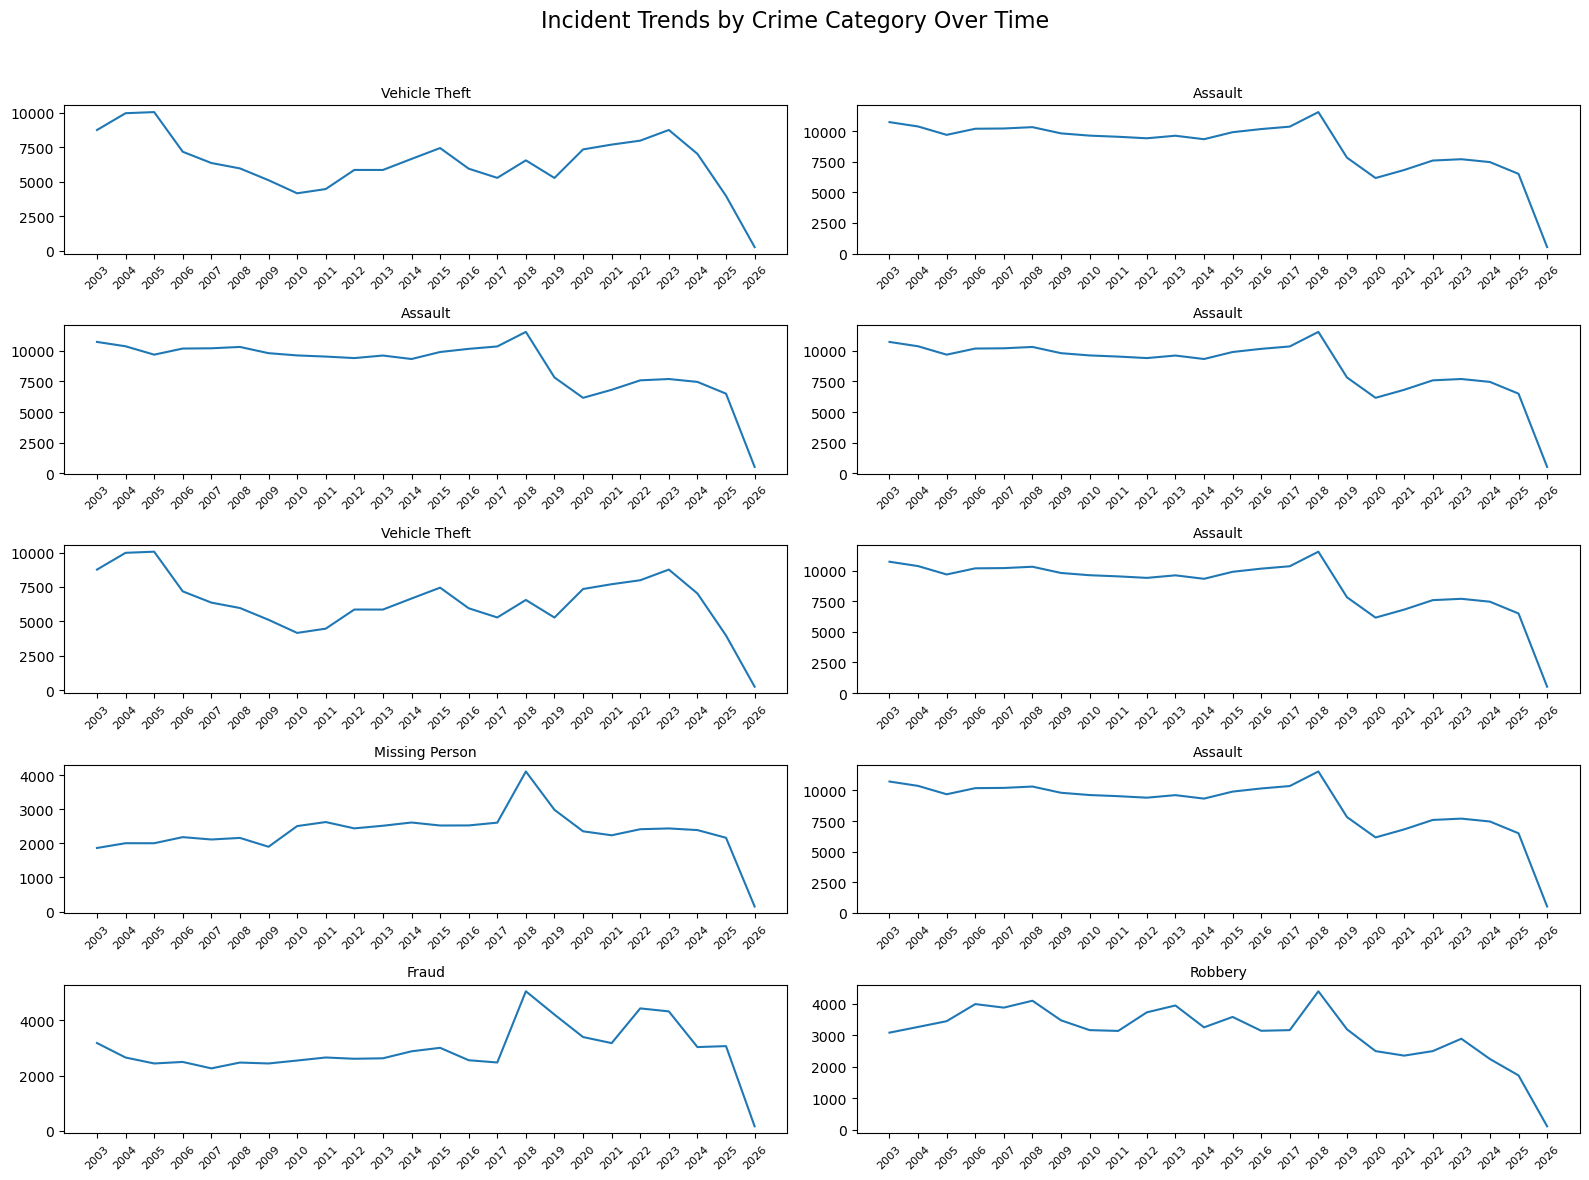

In [17]:
fig, axes = plt.subplots(5, 2, figsize=(16, 12), sharex=False, sharey=False)
axes = axes.flatten()

focus_crimes = data["Focus Crime"]

# Parse to datetime to datetime
data["Incident Date"] = pd.to_datetime(data["Incident Date"])
for ax, crime in zip(axes, focus_crimes):

    counts = (
        data[data["Focus Crime"] == crime]
        .groupby(data["Incident Date"].dt.year)
        .size()
    )

    counts.plot(ax=ax)

    # Set every year on the x-axis
    years = counts.index
    ax.set_xticks(years) 
    ax.set_xticklabels(years, rotation=45, fontsize=8)

    ax.set_title(crime, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Incident Trends by Crime Category Over Time", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

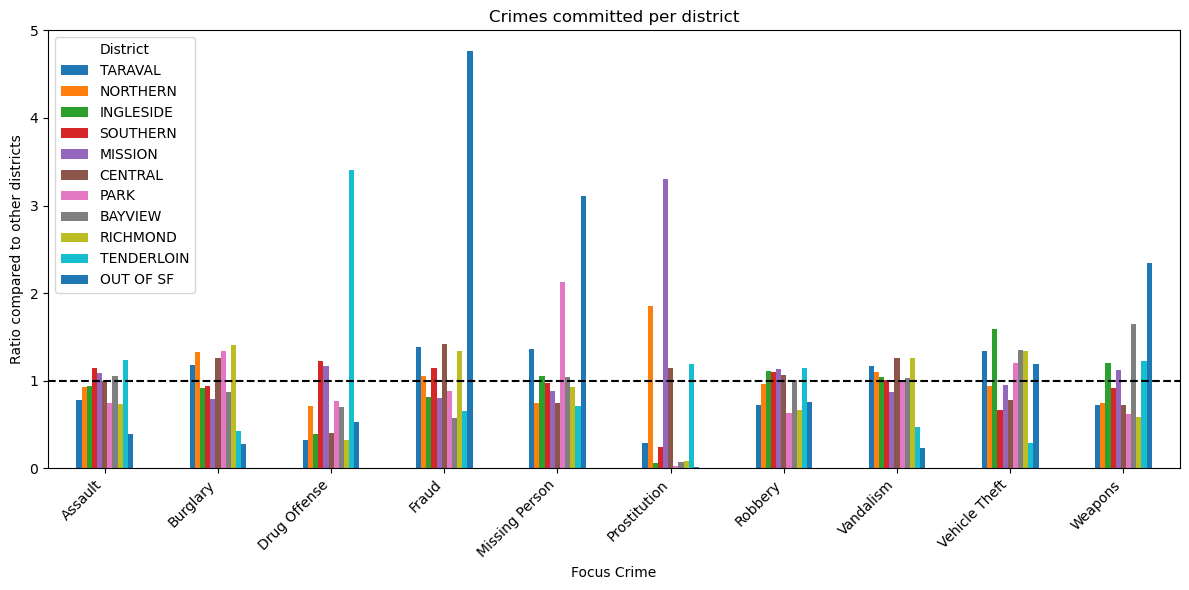

In [36]:
p_crime = data["Focus Crime"].value_counts() / len(data)
p_crime_district = []
for district in data["Police District"].str.upper().unique():
    nr_of_total_crimes = len(data[data["Police District"].str.upper() == district])
    nr_of_crimes = data[data["Police District"].str.upper() == district]["Focus Crime"].value_counts()
    p_crime_district.append((nr_of_crimes / nr_of_total_crimes) / p_crime)

df_combined = pd.concat(p_crime_district, axis=1)

# Assign district names as column labels
df_combined.columns = data["Police District"].str.upper().unique()

# Plot grouped bar chart
df_combined.plot(kind='bar', figsize=(12, 6))

plt.axhline(y=1, color='black', linestyle='--', linewidth=1.5)

plt.xlabel('Focus Crime')
plt.ylabel('Ratio compared to other districts')
plt.title('Crimes committed per district')
plt.xticks(rotation=45, ha='right')
plt.legend(title='District')
plt.tight_layout()
plt.show()

---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

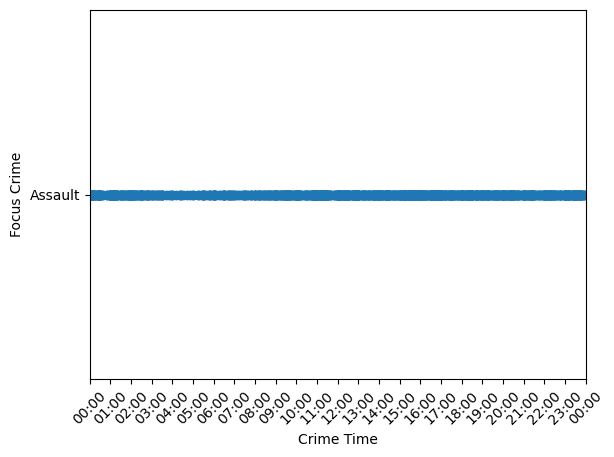

In [53]:
# Part A
# Assault in the last 3 months
new_data = data[data["Focus Crime"] == "Assault"]

three_months = pd.Timestamp.now() - pd.DateOffset(months=3)
new_data = new_data[new_data["Incident Date"] >= three_months]

# Parse to to datetime
new_data["Incident Date"] = pd.to_datetime(data["Incident Date"])
new_data["Incident Time"] = pd.to_datetime(
    "2000-01-01 " + new_data["Incident Time"]
)

plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlim(pd.Timestamp("2000-01-01 00:00"), pd.Timestamp("2000-01-02 00:00"))

plt.xticks(rotation=45)

plt.scatter(new_data["Incident Time"], new_data["Focus Crime"])
plt.xlabel("Crime Time")
plt.ylabel("Focus Crime")
plt.show()


In [ ]:
# Part B


In [ ]:
# Part C